# Multilingual ASR Fine-Tuning (EN + ZH + Mixed)

This notebook trains a Whisper model on your `gold_set` **dev** split and evaluates on **eval**.

Important: `faster-whisper` is an inference runtime (CTranslate2) and is not trained directly in this workflow.
So we do:
1. Baseline inference with `faster-whisper`
2. Fine-tune `openai/whisper-small` with Hugging Face Transformers
3. Evaluate on eval split
4. (Optional) Convert fine-tuned checkpoint to CTranslate2 for faster-whisper inference


In [ ]:
# Colab-safe install (does NOT replace core numpy/torch stack):
%pip install -q --upgrade \
  "faster-whisper>=1.1.0" "transformers>=4.46" \
  "datasets>=3.0.0" "accelerate>=0.34" \
  "jiwer>=3.0,<4" "soundfile>=0.12" "pydub>=0.25" \
  "pandas>=2.0" "matplotlib>=3.8"

# No forced runtime restart.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 154.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 156.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 137.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.

In [ ]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Dict, List

import numpy as np
import torch
from pydub import AudioSegment

from datasets import Dataset
from jiwer import wer as jiwer_wer, cer as jiwer_cer
from faster_whisper import WhisperModel
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
)

# --- Google Drive data source ---
# Set this to your gold_set folder in Drive.
DRIVE_GOLD_SET_DIR = '/content/drive/MyDrive/University/Y2T2/LLM/gold_set'

# Output storage toggle:
# - True  -> save checkpoints in Google Drive
# - False -> save in Colab temporary storage (/content), then download manually
OUTPUT_ON_DRIVE = False
DRIVE_OUTPUT_ROOT = '/content/drive/MyDrive/University/Y2T2/LLM/AAI3008_artifacts'
TMP_OUTPUT_ROOT = '/content/asr_artifacts'


try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as e:
    print(f'Colab drive mount skipped: {e}')

GOLD_SET_DIR = Path(DRIVE_GOLD_SET_DIR)
base_output_root = DRIVE_OUTPUT_ROOT if OUTPUT_ON_DRIVE else TMP_OUTPUT_ROOT
OUTPUT_DIR = Path(base_output_root) / 'asr_finetune_multilingual'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'openai/whisper-small'
MAX_AUDIO_SEC = 30
MAX_TRANSCRIPT_CHARS = 500
BATCH_SIZE = 2
GRAD_ACCUM = 8
LR = 5e-6
NUM_EPOCHS = 8

# Keep model weights in fp32; let Trainer control AMP.
USE_FP16 = False  # set True only after a stable full run
DTYPE = torch.float32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'GOLD_SET_DIR={GOLD_SET_DIR}')
print(f'OUTPUT_DIR={OUTPUT_DIR}')
print(f'DEVICE={DEVICE}, USE_FP16={USE_FP16}')
if not GOLD_SET_DIR.exists():
    raise FileNotFoundError(f'gold_set directory not found: {GOLD_SET_DIR}')


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Mounted at /content/drive
GOLD_SET_DIR=/content/drive/MyDrive/University/Y2T2/LLM/gold_set
OUTPUT_DIR=/content/asr_artifacts/asr_finetune_multilingual
DEVICE=cuda, USE_FP16=False


In [ ]:
def _repair_common_json_issues(raw: str) -> str:
    # Insert missing commas between adjacent objects/arrays.
    fixed = re.sub(r'\}(\s*)\{', r'}\1,{', raw)
    fixed = re.sub(r'\](\s*)\[', r']\1,[', fixed)
    return fixed


def load_json_robust(path: Path):
    raw = path.read_text(encoding='utf-8')
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        repaired = _repair_common_json_issues(raw)
        return json.loads(repaired)


def normalize_lang(lang: str) -> str:
    lang = (lang or '').lower()
    if lang in {'en', 'english'}:
        return 'en'
    if lang in {'zh', 'chinese'}:
        return 'zh'
    if lang in {'mix', 'mixed', 'en+zh'}:
        return 'mixed'
    return lang


def normalize_audio_id(audio_id: str) -> List[str]:
    # Some mixed entries are like clip_mixed_mix_16 while files are clip_mixed_0016.
    ids = [audio_id]
    m = re.match(r'^clip_mixed_mix_(\d+)$', audio_id)
    if m:
        n = int(m.group(1))
        ids.append(f'clip_mixed_{n:04d}')
    return list(dict.fromkeys(ids))


def resolve_audio_path(split: str, lang: str, audio_id: str) -> Path | None:
    folder_map = {'en': 'En', 'zh': 'Zh', 'mixed': 'Mix'}
    lang_folder = folder_map[normalize_lang(lang)]

    split_candidates = [split]
    if split == 'dev':
        split_candidates.append('eval')
    elif split == 'eval':
        split_candidates.append('dev')

    for sp in split_candidates:
        for aid in normalize_audio_id(audio_id):
            cand = GOLD_SET_DIR / sp / lang_folder / f'{aid}.m4a'
            if cand.exists():
                return cand
    return None


def clean_text(text: str) -> str:
    text = (text or '').strip()
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def load_gold_records() -> List[Dict]:
    files = [GOLD_SET_DIR / 'en.json', GOLD_SET_DIR / 'zh.json', GOLD_SET_DIR / 'mix.json']
    records: List[Dict] = []
    missing = []

    for fp in files:
        data = load_json_robust(fp)
        for row in data:
            split = row.get('split', '').lower()
            lang = normalize_lang(row.get('language', ''))
            audio_id = row.get('audio_id', '')
            transcript = clean_text(row.get('transcript', ''))

            if split not in {'dev', 'eval'} or lang not in {'en', 'zh', 'mixed'}:
                continue

            audio_path = resolve_audio_path(split, lang, audio_id)
            if audio_path is None:
                missing.append((split, lang, audio_id))
                continue

            records.append(
                {
                    'record_id': row.get('record_id', audio_id),
                    'split': split,
                    'language': lang,
                    'audio_path': str(audio_path),
                    'transcript': transcript,
                }
            )

    # Deduplicate by actual audio path to avoid duplicated JSON entries.
    dedup = {}
    for r in records:
        dedup[(r['split'], r['audio_path'])] = r
    records = list(dedup.values())

    print(f'Missing audio entries: {len(missing)}')
    if missing:
        print('First few missing:', missing[:8])

    return records


all_records = load_gold_records()
dev_records = [r for r in all_records if r['split'] == 'dev']
eval_records = [r for r in all_records if r['split'] == 'eval']

print('Total records:', len(all_records))
print('Dev records  :', len(dev_records))
print('Eval records :', len(eval_records))
print('Dev language counts:', {k: sum(1 for x in dev_records if x['language'] == k) for k in ['en', 'zh', 'mixed']})
print('Eval language counts:', {k: sum(1 for x in eval_records if x['language'] == k) for k in ['en', 'zh', 'mixed']})


Missing audio entries: 0
Total records: 148
Dev records  : 119
Eval records : 29
Dev language counts: {'en': 38, 'zh': 40, 'mixed': 41}
Eval language counts: {'en': 11, 'zh': 10, 'mixed': 8}


In [ ]:
# Quick baseline inference with faster-whisper on one EN sample.
baseline_model = WhisperModel('small', device=DEVICE, compute_type='float16' if DEVICE == 'cuda' else 'float32')
sample = next(r for r in dev_records if r['language'] == 'en')
segments, info = baseline_model.transcribe(
    sample['audio_path'],
    beam_size=5,
    language='en',
    task='transcribe',
)
pred = ''.join([seg.text for seg in segments]).strip()
print('Sample:', sample['record_id'])
print('Detected language:', info.language, 'prob=', getattr(info, 'language_probability', None))
print('GT :', sample['transcript'][:300])
print('PRED:', pred[:300])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Sample: gold_dev_en_0001
Detected language: en prob= 1
GT : Hello, my name is Daniel Tan, and I am calling to confirm the meeting scheduled for next Wednesday afternoon. My phone number is 9123 4567, and you can reach me anytime after 2 PM. If I am unavailable, please leave a message and I will return your call as soon as possible. Thank you. Actually, since
PRED: Hello, my name is Daniel Tan and I am calling to confirm the meeting scheduled for next Wednesday afternoon. My phone number is 91234567 and you can reach me anytime after 2pm. If I am unavailable, please leave a message and I will return your call as soon as possible. Thank you. Actually since we a


In [ ]:
def load_audio_mono_16k(path: str):
    audio = AudioSegment.from_file(path)
    audio = audio.set_frame_rate(16000).set_channels(1)
    arr = np.array(audio.get_array_of_samples())
    max_val = float(1 << (8 * audio.sample_width - 1))
    arr = arr.astype(np.float32) / max_val
    return arr, 16000


def audio_duration_sec(path: str) -> float:
    audio = AudioSegment.from_file(path)
    return len(audio) / 1000.0


processor = WhisperProcessor.from_pretrained(MODEL_NAME, task='transcribe')
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME, torch_dtype=DTYPE)
if DEVICE == 'cuda':
    model = model.to('cuda')

# Use task-only generation defaults to avoid translate behavior.
if hasattr(model, 'generation_config'):
    model.generation_config.task = 'transcribe'
    model.generation_config.language = None

max_input_len = MAX_AUDIO_SEC * 16000
max_label_len = int(getattr(model.config, 'max_target_positions', 448))


def tokenize_with_language_prompt(text: str, lang: str):
    if lang == 'en':
        processor.tokenizer.set_prefix_tokens(language='english', task='transcribe')
    elif lang == 'zh':
        processor.tokenizer.set_prefix_tokens(language='chinese', task='transcribe')
    else:
        # mixed language: keep task prompt only and let model infer language
        processor.tokenizer.set_prefix_tokens(task='transcribe')

    return processor.tokenizer(text, truncation=True, max_length=max_label_len).input_ids


def filter_records(records: List[Dict], split_name: str) -> List[Dict]:
    kept = []
    dropped_long_chars = 0
    dropped_long_audio = 0
    dropped_empty = 0

    for r in records:
        txt = (r['transcript'] or '').strip()
        if not txt:
            dropped_empty += 1
            continue
        if len(txt) > MAX_TRANSCRIPT_CHARS:
            dropped_long_chars += 1
            continue

        dur = audio_duration_sec(r['audio_path'])
        if dur > MAX_AUDIO_SEC:
            # Whisper encoder window is 30s; skip overlong clips to preserve alignment quality.
            dropped_long_audio += 1
            continue

        kept.append(r)

    print(f'[{split_name}] kept={len(kept)} dropped_empty={dropped_empty} dropped_long_chars={dropped_long_chars} dropped_long_audio={dropped_long_audio}')
    return kept


dev_records_f = filter_records(dev_records, 'dev')
eval_records_f = filter_records(eval_records, 'eval')


def prepare_example(example):
    audio_array, sr = load_audio_mono_16k(example['audio_path'])
    if len(audio_array) > max_input_len:
        audio_array = audio_array[:max_input_len]

    feat = processor.feature_extractor(
        audio_array,
        sampling_rate=sr,
        return_tensors='pt',
        return_attention_mask=True,
    )
    input_features = feat.input_features[0]
    attention_mask = feat.attention_mask[0]

    labels = tokenize_with_language_prompt(example['transcript'], example['language'])

    return {
        'input_features': input_features,
        'attention_mask': attention_mask,
        'labels': labels,
        'transcript': example['transcript'],
        'language': example['language'],
    }


train_raw = Dataset.from_list(dev_records_f)
valid_raw = Dataset.from_list(eval_records_f)
train_ds = train_raw.map(prepare_example, remove_columns=train_raw.column_names)
valid_ds = valid_raw.map(prepare_example, remove_columns=valid_raw.column_names)

print(train_ds)
print(valid_ds)

max_train_label_len = max(len(x) for x in train_ds['labels']) if len(train_ds) else 0
max_valid_label_len = max(len(x) for x in valid_ds['labels']) if len(valid_ds) else 0
print(f'max train label tokens: {max_train_label_len}')
print(f'max eval label tokens : {max_valid_label_len}')


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

generation_config.json: 0.00B [00:00, ?B/s]

[dev] kept=82 dropped_empty=0 dropped_long_chars=32 dropped_long_audio=5
[eval] kept=20 dropped_empty=0 dropped_long_chars=9 dropped_long_audio=0


Map:   0%|          | 0/82 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Dataset({
    features: ['language', 'transcript', 'input_features', 'attention_mask', 'labels'],
    num_rows: 82
})
Dataset({
    features: ['language', 'transcript', 'input_features', 'attention_mask', 'labels'],
    num_rows: 20
})
max train label tokens: 84
max eval label tokens : 78


In [ ]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union



@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [
            {'input_features': f['input_features'], 'attention_mask': f['attention_mask']}
            for f in features
        ]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors='pt')

        label_features = [{'input_ids': f['labels']} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors='pt')

        labels = labels_batch['input_ids'].masked_fill(labels_batch.attention_mask.ne(1), -100)

        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch['labels'] = labels
        return batch


data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)


def _to_wer_tokens(s: str) -> str:
    s = (s or '').strip()
    # For scripts without whitespace (e.g. Chinese), compute WER on characters.
    if ' ' not in s:
        return ' '.join(list(s))
    return s


def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    pred_norm = [re.sub(r'\s+', ' ', x).strip() for x in pred_str]
    label_norm = [re.sub(r'\s+', ' ', x).strip() for x in label_str]

    wer_pred = [_to_wer_tokens(x) for x in pred_norm]
    wer_ref = [_to_wer_tokens(x) for x in label_norm]

    wer = 100 * jiwer_wer(wer_ref, wer_pred)
    cer = 100 * jiwer_cer(label_norm, pred_norm)
    return {'wer': wer, 'cer': cer}


In [ ]:
import inspect

args_kwargs = dict(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_steps=50,
    num_train_epochs=NUM_EPOCHS,
    save_strategy='no',  # do not save epoch checkpoints
    logging_steps=10,
    predict_with_generate=True,
    generation_max_length=128,
    fp16=USE_FP16,
    report_to='none',
    disable_tqdm=True,
    load_best_model_at_end=False,
    dataloader_num_workers=0,
    remove_unused_columns=False,
    bf16=False,
)

# transformers compatibility: some versions use eval_strategy, others evaluation_strategy
sig = inspect.signature(Seq2SeqTrainingArguments.__init__)
if 'evaluation_strategy' in sig.parameters:
    args_kwargs['evaluation_strategy'] = 'epoch'
else:
    args_kwargs['eval_strategy'] = 'epoch'

# Optional size saver: drop optimizer/scheduler states if supported.
if 'save_only_model' in sig.parameters:
    args_kwargs['save_only_model'] = True

training_args = Seq2SeqTrainingArguments(**args_kwargs)

trainer_kwargs = dict(
    args=training_args,
    model=model,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_sig = inspect.signature(Seq2SeqTrainer.__init__)
if 'tokenizer' in trainer_sig.parameters:
    trainer_kwargs['tokenizer'] = processor.feature_extractor
elif 'processing_class' in trainer_sig.parameters:
    trainer_kwargs['processing_class'] = processor

trainer = Seq2SeqTrainer(**trainer_kwargs)



In [ ]:
from pathlib import Path
import shutil


def _dir_size_mb(path: Path) -> float:
    total = 0
    for f in path.rglob('*'):
        if f.is_file():
            total += f.stat().st_size
    return total / (1024 ** 2)


def keep_only_best_checkpoint(output_dir: Path, best_name: str = 'best_checkpoint') -> None:
    best_dir = output_dir / best_name
    for p in output_dir.iterdir():
        if p.resolve() == best_dir.resolve():
            continue
        if p.is_dir():
            shutil.rmtree(p, ignore_errors=True)
        else:
            p.unlink(missing_ok=True)


train_result = trainer.train()

best_dir = OUTPUT_DIR / 'best_checkpoint'
best_dir.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(best_dir))
processor.save_pretrained(str(best_dir))
print(f'best_checkpoint saved at: {best_dir}')

# Enforce only best_checkpoint remains inside artifacts output folder.
keep_only_best_checkpoint(OUTPUT_DIR, best_name='best_checkpoint')

print(f"OUTPUT_DIR size: {_dir_size_mb(OUTPUT_DIR):.2f} MB")
print('OUTPUT_DIR entries:', [p.name for p in sorted(OUTPUT_DIR.iterdir())])


A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


{'eval_loss': '1.754', 'eval_wer': '102.8', 'eval_cer': '79.07', 'eval_runtime': '14.98', 'eval_samples_per_second': '1.335', 'eval_steps_per_second': '0.667', 'epoch': '1'}
{'loss': '13.44', 'grad_norm': '29.1', 'learning_rate': '9e-07', 'epoch': '1.78'}
{'eval_loss': '1.548', 'eval_wer': '102.8', 'eval_cer': '78.73', 'eval_runtime': '14.59', 'eval_samples_per_second': '1.37', 'eval_steps_per_second': '0.685', 'epoch': '2'}
{'eval_loss': '1.319', 'eval_wer': '93.63', 'eval_cer': '72.06', 'eval_runtime': '14.59', 'eval_samples_per_second': '1.371', 'eval_steps_per_second': '0.686', 'epoch': '3'}
{'loss': '9.909', 'grad_norm': '12.82', 'learning_rate': '1.9e-06', 'epoch': '3.39'}
{'eval_loss': '1.163', 'eval_wer': '85.37', 'eval_cer': '63.99', 'eval_runtime': '14.41', 'eval_samples_per_second': '1.388', 'eval_steps_per_second': '0.694', 'epoch': '4'}
{'loss': '7.62', 'grad_norm': '2.465', 'learning_rate': '2.9e-06', 'epoch': '5'}
{'eval_loss': '1.012', 'eval_wer': '69.88', 'eval_cer': '

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

best_checkpoint saved at: /content/asr_artifacts/asr_finetune_multilingual/best_checkpoint
OUTPUT_DIR size: 925.96 MB
OUTPUT_DIR entries: ['best_checkpoint']


In [ ]:
# Per-language eval breakdown using explicit language-constrained decoding.
# This avoids cross-language translation drift from generic trainer.generate().
import pandas as pd


def _to_wer_tokens(s: str) -> str:
    s = (s or "").strip()
    if " " not in s:
        return " ".join(list(s))
    return s


def _decode_for_metrics(record: dict, max_decode_len: int = 128):
    audio_array, sr = load_audio_mono_16k(record['audio_path'])
    feat = processor.feature_extractor(
        audio_array,
        sampling_rate=sr,
        return_tensors='pt',
        return_attention_mask=True,
    )
    input_features = feat.input_features.to(model.device)
    attention_mask = feat.attention_mask.to(model.device)

    if record['language'] == 'en':
        forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(language='english', task='transcribe')
    elif record['language'] == 'zh':
        forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(language='chinese', task='transcribe')
    else:
        forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(task='transcribe')

    with torch.no_grad():
        pred_ids = model.generate(
            input_features=input_features,
            attention_mask=attention_mask,
            forced_decoder_ids=forced_decoder_ids,
            max_length=max_decode_len,
        )

    pred = processor.tokenizer.decode(pred_ids[0], skip_special_tokens=True).strip()
    ref = (record['transcript'] or '').strip()
    pred = re.sub(r'\s+', ' ', pred).strip()
    ref = re.sub(r'\s+', ' ', ref).strip()

    wer = 100 * jiwer_wer([_to_wer_tokens(ref)], [_to_wer_tokens(pred)])
    cer = 100 * jiwer_cer([ref], [pred])
    return {'language': record['language'], 'wer': wer, 'cer': cer}


rows = [_decode_for_metrics(r) for r in eval_records_f]
df_lang = pd.DataFrame(rows)
print(df_lang.groupby('language')[['wer', 'cer']].mean().round(2))


             wer     cer
language                
en         20.09    7.35
mixed     131.63   54.81
zh        293.98  226.22


Per-language means:
             wer     cer
language                
en         20.09    7.35
mixed     131.63   54.81
zh        293.98  226.22

=== EN samples ===

[gold_eval_en_0045] audio=21.6s WER=19.15 CER=4.00
REF : Hey, Pepe here. I recently moved, so I updated my address to woodlands, and I just wanted to confirm that it’s reflected in the system. My contact number is 9781 8690 , and my email remains pepe@gmail.com . Please let me know if there are a
PRED: Hey, Pepe here. I recently moved, so I updated my address to Woodlands, and I just wanted to confirm that it is reflected in the system. My contact number is 97818690, and my email remains pepe at gmail.com. Please let me know if there are 

[gold_eval_en_0050] audio=20.8s WER=44.74 CER=14.16
REF : Good evening, Benzema here. I registered earlier today and just wanted to make sure my contact details are accurate. My email is benzama@gmail.com, my phone is 9426 1264, and my ID is 3. Looking forward to hearing back.
PRED: Good

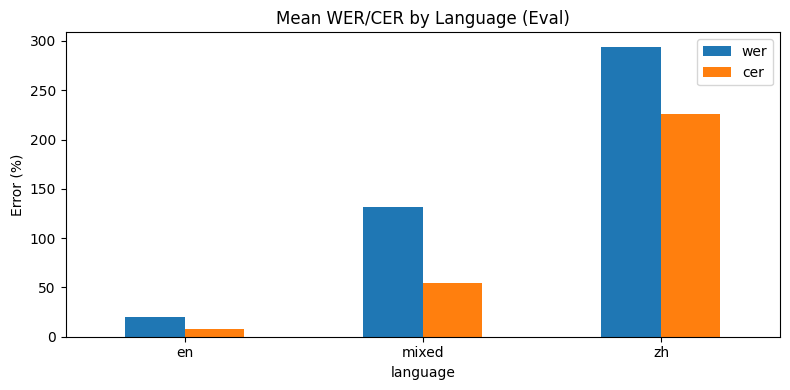

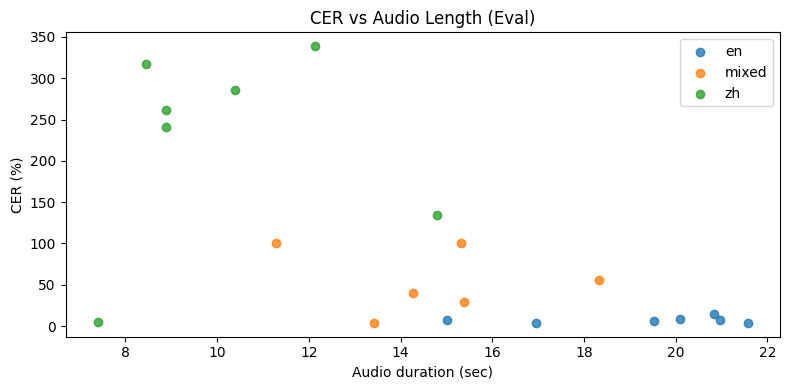

Saved detailed eval predictions: /content/eval_predictions_detailed.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def _to_wer_tokens(s: str) -> str:
    s = (s or '').strip()
    if ' ' not in s:
        return ' '.join(list(s))
    return s


def transcribe_record(record: dict, max_decode_len: int = 128) -> dict:
    audio_array, sr = load_audio_mono_16k(record['audio_path'])
    feat = processor.feature_extractor(
        audio_array,
        sampling_rate=sr,
        return_tensors='pt',
        return_attention_mask=True,
    )
    input_features = feat.input_features.to(model.device)
    attention_mask = feat.attention_mask.to(model.device)

    # Hard-force language for known single-language samples to prevent translation/drift.
    if record['language'] == 'en':
        forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(language='english', task='transcribe')
    elif record['language'] == 'zh':
        forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(language='chinese', task='transcribe')
    else:
        # Mixed language: do not force a single language token.
        forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(task='transcribe')

    with torch.no_grad():
        pred_ids = model.generate(
            input_features=input_features,
            attention_mask=attention_mask,
            forced_decoder_ids=forced_decoder_ids,
            max_length=max_decode_len,
        )

    pred_text = processor.tokenizer.decode(pred_ids[0], skip_special_tokens=True).strip()
    ref_text = (record['transcript'] or '').strip()

    pred_norm = re.sub(r'\s+', ' ', pred_text).strip()
    ref_norm = re.sub(r'\s+', ' ', ref_text).strip()

    wer = 100 * jiwer_wer([_to_wer_tokens(ref_norm)], [_to_wer_tokens(pred_norm)])
    cer = 100 * jiwer_cer([ref_norm], [pred_norm])

    return {
        'record_id': record['record_id'],
        'language': record['language'],
        'audio_sec': audio_duration_sec(record['audio_path']),
        'ref_text': ref_norm,
        'pred_text': pred_norm,
        'wer': wer,
        'cer': cer,
    }


model.eval()
rows = [transcribe_record(r) for r in eval_records_f]
df = pd.DataFrame(rows)

print('Per-language means:')
print(df.groupby('language')[['wer', 'cer']].mean().round(2))

# Show sample predictions (best and worst CER per language)
for lang in ['en', 'zh', 'mixed']:
    sub = df[df['language'] == lang].sort_values('cer')
    if sub.empty:
        continue
    print(f"\n=== {lang.upper()} samples ===")
    for _, row in pd.concat([sub.head(1), sub.tail(1)]).drop_duplicates(subset=['record_id']).iterrows():
        print(f"\n[{row['record_id']}] audio={row['audio_sec']:.1f}s WER={row['wer']:.2f} CER={row['cer']:.2f}")
        print('REF :', row['ref_text'][:240])
        print('PRED:', row['pred_text'][:240])

# Plot 1: Mean WER/CER by language
lang_stats = df.groupby('language', as_index=False)[['wer', 'cer']].mean()
ax = lang_stats.plot(x='language', y=['wer', 'cer'], kind='bar', figsize=(8, 4), rot=0)
ax.set_title('Mean WER/CER by Language (Eval)')
ax.set_ylabel('Error (%)')
plt.tight_layout()
plt.show()

# Plot 2: CER vs audio duration
fig, ax = plt.subplots(figsize=(8, 4))
for lang, grp in df.groupby('language'):
    ax.scatter(grp['audio_sec'], grp['cer'], label=lang, alpha=0.8)
ax.set_title('CER vs Audio Length (Eval)')
ax.set_xlabel('Audio duration (sec)')
ax.set_ylabel('CER (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Save detailed per-sample predictions
pred_path = Path('/content/eval_predictions_detailed.csv')
df.to_csv(pred_path, index=False, encoding='utf-8')
print(f'Saved detailed eval predictions: {pred_path}')



In [ ]:
import shutil
from pathlib import Path

best_dir = OUTPUT_DIR / 'best_checkpoint'
if not best_dir.exists():
    raise FileNotFoundError(f'best_checkpoint not found at: {best_dir}')

zip_base = Path('/content') / 'best_checkpoint_export'
zip_path = shutil.make_archive(str(zip_base), 'zip', root_dir=str(best_dir))
print(f'Created zip: {zip_path}')
print(f'Zip size: {Path(zip_path).stat().st_size / (1024**2):.2f} MB')

# In Colab, this triggers browser download.
try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print(f'Auto-download unavailable in this environment: {e}')
    print('Manual path:', zip_path)


Created zip: /content/best_checkpoint_export.zip
Zip size: 855.43 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from pathlib import Path

# Set your target folder in Google Drive
DRIVE_TARGET_DIR = Path('/content/drive/MyDrive/University/Y2T2/LLM/AAI3008_artifacts')

best_dir = OUTPUT_DIR / 'best_checkpoint'
if not best_dir.exists():
    raise FileNotFoundError(f'best_checkpoint not found at: {best_dir}')

# Ensure Drive is mounted
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as e:
    print(f'Drive mount skipped/unavailable: {e}')

DRIVE_TARGET_DIR.mkdir(parents=True, exist_ok=True)
dest_dir = DRIVE_TARGET_DIR / 'best_checkpoint_v4'

# Overwrite destination if it already exists
if dest_dir.exists():
    shutil.rmtree(dest_dir)

shutil.copytree(best_dir, dest_dir)

# Optional: quick size summary
size_mb = sum(f.stat().st_size for f in dest_dir.rglob('*') if f.is_file()) / (1024**2)
print(f'Copied best_checkpoint to: {dest_dir}')
print(f'Destination size: {size_mb:.2f} MB')
print('Destination entries:', [p.name for p in sorted(dest_dir.iterdir())])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied best_checkpoint to: /content/drive/MyDrive/University/Y2T2/LLM/AAI3008_artifacts/best_checkpoint_v4
Destination size: 925.96 MB
Destination entries: ['config.json', 'generation_config.json', 'model.safetensors', 'processor_config.json', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


## Optional: convert fine-tuned model to CTranslate2 for faster-whisper

Run this in shell after training:

```bash
ct2-transformers-converter --model artifacts/asr_finetune_multilingual/best_checkpoint --output_dir artifacts/asr_finetune_multilingual/ct2 --copy_files tokenizer.json preprocessor_config.json
```

Then load with faster-whisper:

```python
from faster_whisper import WhisperModel
model = WhisperModel('artifacts/asr_finetune_multilingual/ct2', device='cuda', compute_type='float16')
```
